<a href="https://colab.research.google.com/github/lorenzochesta/progetto_data_science/blob/main/Confronto_metodi_discesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
X, y = load_breast_cancer(return_X_y=True)

In [ ]:
# Split del dataset: 80% Training Set, 20% Test Set
# stratify=y garantisce che la percentuale di positivi e negativi sia la stessa nel training set e nel test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Pre-processing

In [ ]:
# Standardizzazione
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Aggiungo una colonna di 1 all'inizio per poter gestire w0 insieme agli altri pesi (w0 * 1)
X_train = np.c_[np.ones(X_train.shape[0]),X_train]
X_test = np.c_[np.ones(X_test.shape[0]),X_test]

## Modello

sklearn.linear_model.LogisticRegression non permette di definire l'ottimizzatore e il passo. Implemento perciò una Logistic Regression da zero con NumPy.

In [ ]:
# Sigmoide
def sigmoid(z):
    return 1/(1 + np.exp(-z))

# Loss: Binary Cross-Entropy
def calcola_loss(X,y,W):
    N = len(y) # numero totale di esempi
    h = sigmoid(X @ W) # X @ W: prodotto scalare tra X e vettore dei pesi W
    return -np.mean(y * np.log(h + 1e-15) + (1 - y) * np.log(1 -h + 1e-15)) # aggiungo 1e-15 per evitare log(0)

# Gradiente
def calcola_gradiente(X,y,W):
    N = len(y)
    h = sigmoid(X @ W)
    return (X.T @ (h - y)) / N # (h - y) vettore degli errori di predizione

# Hessiana
def calcola_hessiana(X,y,W):
    N = len(y)
    h = sigmoid(X @ W)
    W = h * (1 - h)
    return (X.T @ (W[:, None] * X)) / N # (W[:, None] * X) moltiplica ogni riga di X per il rispettivo wi

## Training e Test

Confronto Gradient Descent, Stochastic Gradient Descent e Metodo di Newton.

### Gradient Descent

Ad ogni epoca, calcola il gradiente sull'intero dataset e aggiorna i pesi una volta sola.

Epoca 0001/100 Loss corrente: 0.520303
Epoca 0002/100 Loss corrente: 0.432024
Epoca 0003/100 Loss corrente: 0.378063
Epoca 0004/100 Loss corrente: 0.340960
Epoca 0005/100 Loss corrente: 0.313498
Epoca 0006/100 Loss corrente: 0.292132
Epoca 0007/100 Loss corrente: 0.274900
Epoca 0008/100 Loss corrente: 0.260620
Epoca 0009/100 Loss corrente: 0.248533
Epoca 0010/100 Loss corrente: 0.238129
Epoca 0011/100 Loss corrente: 0.229049
Epoca 0012/100 Loss corrente: 0.221034
Epoca 0013/100 Loss corrente: 0.213891
Epoca 0014/100 Loss corrente: 0.207473
Epoca 0015/100 Loss corrente: 0.201665
Epoca 0016/100 Loss corrente: 0.196378
Epoca 0017/100 Loss corrente: 0.191538
Epoca 0018/100 Loss corrente: 0.187088
Epoca 0019/100 Loss corrente: 0.182978
Epoca 0020/100 Loss corrente: 0.179168
Epoca 0021/100 Loss corrente: 0.175624
Epoca 0022/100 Loss corrente: 0.172318
Epoca 0023/100 Loss corrente: 0.169224
Epoca 0024/100 Loss corrente: 0.166322
Epoca 0025/100 Loss corrente: 0.163593
Epoca 0026/100 Loss corre

<function matplotlib.pyplot.show(close=None, block=None)>

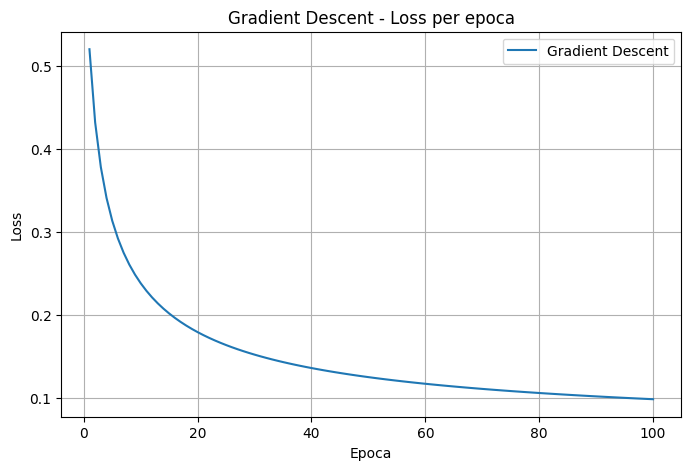

In [ ]:
# Inizializzazione del vettore dei pesi W
n_features = X_train.shape[1]
W = np.zeros(n_features)

alpha = 0.1 # passo
epochs = 100

loss_history_gd = []
start = time.perf_counter()

for epoch in range(1,epochs+1):
    grad = calcola_gradiente(X_train,y_train,W)
    W = W - alpha * grad
    current_loss = calcola_loss(X_train,y_train,W)

    loss_history_gd.append(current_loss)

    print(f"Epoca {epoch:04d}/{epochs} Loss corrente: {current_loss:.6f}")

end = time.perf_counter()

print(f"Tempo di addestramento: {end - start:.4f} s")

y_probs_train = sigmoid(X_train @ W) # probabilità predette
y_pred_train = (y_probs_train >= 0.5).astype(int) # conversione in classi 0 o 1 (soglia a 0.5)

acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("Metriche di Training:")
print(f"Accuracy:  {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall:    {rec_train:.4f}")
print(f"F1-Score:  {f1_train:.4f}")
print("\nMatrice di Confusione (Training):")
print(cm_train)

plt.figure(figsize=(8,5))
plt.plot(range(1,epochs+1),loss_history_gd,color='tab:blue',label='Gradient Descent')
plt.title("Gradient Descent - Loss per epoca")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show

In [ ]:
# Test GD
y_probs_test = sigmoid(X_test @ W)
y_pred_test = (y_probs_test >= 0.5).astype(int)

test_loss = calcola_loss(X_test,y_test,W)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print("Metriche di Test:")
print(f"Loss sul Test Set: {test_loss:.6f}\n")
print(f"Accuracy:  {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall:    {rec_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")
print("\nMatrice di Confusione (Test):")
print(cm_test)

Metriche di Test:
Loss sul Test Set: 0.125958

Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1-Score:  0.9790

Matrice di Confusione (Test):
[[41  1]
 [ 2 70]]


### Stochastic Gradient Descent

Ad ogni epoca, aggiorna i pesi più volte:
- caso estremo: calcola il gradiente su un solo esempio, aggiorna i pesi e passa all'esemipo successivo;
- caso mini-batch: calcola il gradiente su un gruppo di esempi, aggiorna i pesi e passa al gruppo di esempi successivo.

Epoca 01/100 Loss corrente: 0.069510
Epoca 02/100 Loss corrente: 0.058384
Epoca 03/100 Loss corrente: 0.055896
Epoca 04/100 Loss corrente: 0.057390
Epoca 05/100 Loss corrente: 0.051880
Epoca 06/100 Loss corrente: 0.050000
Epoca 07/100 Loss corrente: 0.050509
Epoca 08/100 Loss corrente: 0.048158
Epoca 09/100 Loss corrente: 0.046672
Epoca 10/100 Loss corrente: 0.047931
Epoca 11/100 Loss corrente: 0.045431
Epoca 12/100 Loss corrente: 0.045789
Epoca 13/100 Loss corrente: 0.047296
Epoca 14/100 Loss corrente: 0.045591
Epoca 15/100 Loss corrente: 0.043624
Epoca 16/100 Loss corrente: 0.045909
Epoca 17/100 Loss corrente: 0.047721
Epoca 18/100 Loss corrente: 0.045290
Epoca 19/100 Loss corrente: 0.043850
Epoca 20/100 Loss corrente: 0.046230
Epoca 21/100 Loss corrente: 0.042458
Epoca 22/100 Loss corrente: 0.044909
Epoca 23/100 Loss corrente: 0.042363
Epoca 24/100 Loss corrente: 0.044925
Epoca 25/100 Loss corrente: 0.043335
Epoca 26/100 Loss corrente: 0.042093
Epoca 27/100 Loss corrente: 0.042606
E

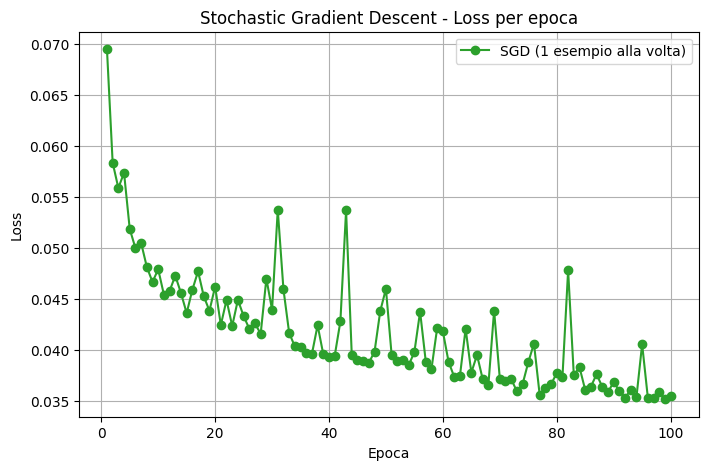

In [ ]:
# Caso estremo (1 esempio)
n_features = X_train.shape[1]
W = np.zeros(n_features)

alpha = 0.1 # passo
epochs = 100
N = len(y_train)

loss_history_sgd1 = []
start = time.perf_counter()

for epoch in range(1,epochs+1):
    # shuffle dei dati
    indices = np.random.permutation(N)

    # aggiorno i pesi per ogni esempio
    for i in indices:
        xi = X_train[i:i+1]
        yi = y_train[i:i+1]

        grad = calcola_gradiente(xi,yi,W)
        W = W - alpha * grad

    current_loss = calcola_loss(X_train,y_train,W)
    loss_history_sgd1.append(current_loss)

    print(f"Epoca {epoch:02d}/{epochs} Loss corrente: {current_loss:.6f}")

end = time.perf_counter()

print(f"Tempo di addestramento: {end - start:.4f} s")

y_probs_train = sigmoid(X_train @ W) # probabilità predette
y_pred_train = (y_probs_train >= 0.5).astype(int) # conversione in classi 0 o 1 (soglia a 0.5)

acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("Metriche di Training:")
print(f"Accuracy:  {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall:    {rec_train:.4f}")
print(f"F1-Score:  {f1_train:.4f}")
print("\nMatrice di Confusione (Training):")
print(cm_train)

plt.figure(figsize=(8,5))
plt.plot(range(1,epochs+1), loss_history_sgd1, marker='o', color='tab:green', label='SGD (1 esempio alla volta)')
plt.title("Stochastic Gradient Descent - Loss per epoca")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Test SGD (1 esempio)
y_probs_test = sigmoid(X_test @ W)
y_pred_test = (y_probs_test >= 0.5).astype(int)

test_loss = calcola_loss(X_test,y_test,W)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print("Metriche di Test:")
print(f"Loss sul Test Set: {test_loss:.6f}\n")
print(f"Accuracy:  {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall:    {rec_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")
print("\nMatrice di Confusione (Test):")
print(cm_test)

Metriche di Test:
Loss sul Test Set: 0.083354

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

Matrice di Confusione (Test):
[[41  1]
 [ 1 71]]


Epoca 001/100 Loss corrente: 0.199680
Epoca 002/100 Loss corrente: 0.153841
Epoca 003/100 Loss corrente: 0.130326
Epoca 004/100 Loss corrente: 0.116727
Epoca 005/100 Loss corrente: 0.107956
Epoca 006/100 Loss corrente: 0.101475
Epoca 007/100 Loss corrente: 0.096562
Epoca 008/100 Loss corrente: 0.092548
Epoca 009/100 Loss corrente: 0.089345
Epoca 010/100 Loss corrente: 0.086516
Epoca 011/100 Loss corrente: 0.084045
Epoca 012/100 Loss corrente: 0.082000
Epoca 013/100 Loss corrente: 0.080225
Epoca 014/100 Loss corrente: 0.078628
Epoca 015/100 Loss corrente: 0.077253
Epoca 016/100 Loss corrente: 0.076068
Epoca 017/100 Loss corrente: 0.074887
Epoca 018/100 Loss corrente: 0.073957
Epoca 019/100 Loss corrente: 0.073077
Epoca 020/100 Loss corrente: 0.072130
Epoca 021/100 Loss corrente: 0.071379
Epoca 022/100 Loss corrente: 0.070577
Epoca 023/100 Loss corrente: 0.069841
Epoca 024/100 Loss corrente: 0.069167
Epoca 025/100 Loss corrente: 0.068624
Epoca 026/100 Loss corrente: 0.067993
Epoca 027/10

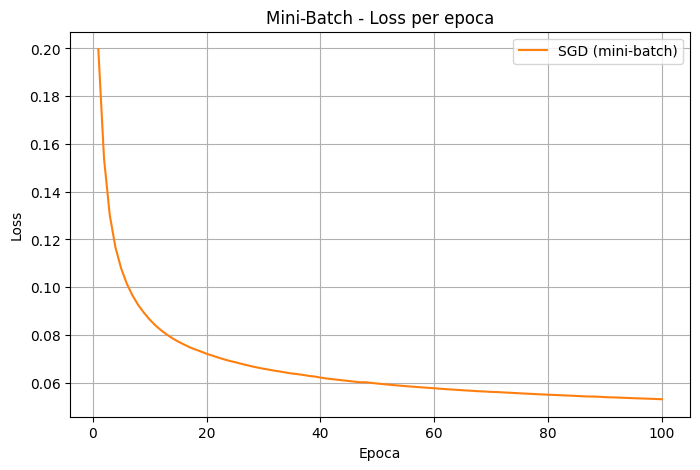

In [ ]:
# Caso mini/batch
n_features = X_train.shape[1]
W = np.zeros(n_features)

alpha = 0.1 # passo
epochs = 100
N = len(y_train)
batch_size = 32

loss_history_sgd_mb = []
start = time.perf_counter()

for epoch in range(1,epochs+1):
    # shuffle
    indices = np.random.permutation(N)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # divido in mini-batch
    for i in range(0,N,batch_size):
        xb = X_shuffled[i:i+batch_size]
        yb = y_shuffled[i:i+batch_size]

        grad = calcola_gradiente(xb,yb,W)
        W = W - alpha * grad

    current_loss = calcola_loss(X_train,y_train,W)
    loss_history_sgd_mb.append(current_loss)

    print(f"Epoca {epoch:03d}/{epochs} Loss corrente: {current_loss:.6f}")

end = time.perf_counter()

print(f"Tempo di addestramento: {end - start:.4f} s")

y_probs_train = sigmoid(X_train @ W) # probabilità predette
y_pred_train = (y_probs_train >= 0.5).astype(int) # conversione in classi 0 o 1 (soglia a 0.5)

acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("Metriche di Training:")
print(f"Accuracy:  {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall:    {rec_train:.4f}")
print(f"F1-Score:  {f1_train:.4f}")
print("\nMatrice di Confusione (Training):")
print(cm_train)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history_sgd_mb, color='tab:orange', label='SGD (mini-batch)')
plt.title("Mini-Batch - Loss per epoca")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Test SGD (mini-batch)
y_probs_test = sigmoid(X_test @ W)
y_pred_test = (y_probs_test >= 0.5).astype(int)

test_loss = calcola_loss(X_test,y_test,W)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print("Metriche di Test:")
print(f"Loss sul Test Set: {test_loss:.6f}\n")
print(f"Accuracy:  {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall:    {rec_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")
print("\nMatrice di Confusione (Test):")
print(cm_test)

Metriche di Test:
Loss sul Test Set: 0.080909

Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1-Score:  0.9790

Matrice di Confusione (Test):
[[41  1]
 [ 2 70]]


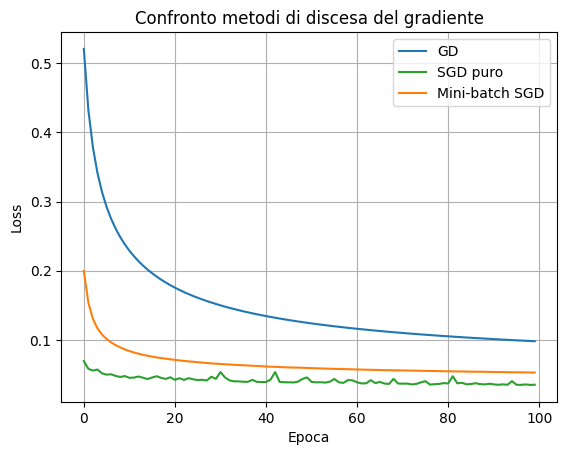

In [ ]:
# Confronto l'addestramento tramite GD, SGD (1 esempio) e SGD mini-batch
plt.plot(loss_history_gd, color='tab:blue', label="GD")
plt.plot(loss_history_sgd1, color='tab:green', label="SGD puro")
plt.plot(loss_history_sgd_mb, color='tab:orange', label="Mini-batch SGD")

plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Confronto metodi di discesa del gradiente")
plt.grid(True)
plt.legend()
plt.show()

### Metodo di Newton

Oltre al gradiente, sfrutto l'Hessiana. Assumo passo unitario (alpha = 1). Riduco il numero di iterazioni.

Iterazione 01/6 Loss corrente: 0.231840
Iterazione 02/6 Loss corrente: 0.129880
Iterazione 03/6 Loss corrente: 0.081901
Iterazione 04/6 Loss corrente: 0.056490
Iterazione 05/6 Loss corrente: 0.040030
Iterazione 06/6 Loss corrente: 0.027557
Tempo di addestramento: 0.0045 s
Metriche di Training:
Accuracy:  0.9912
Precision: 0.9895
Recall:    0.9965
F1-Score:  0.9930

Matrice di Confusione (Training):
[[167   3]
 [  1 284]]


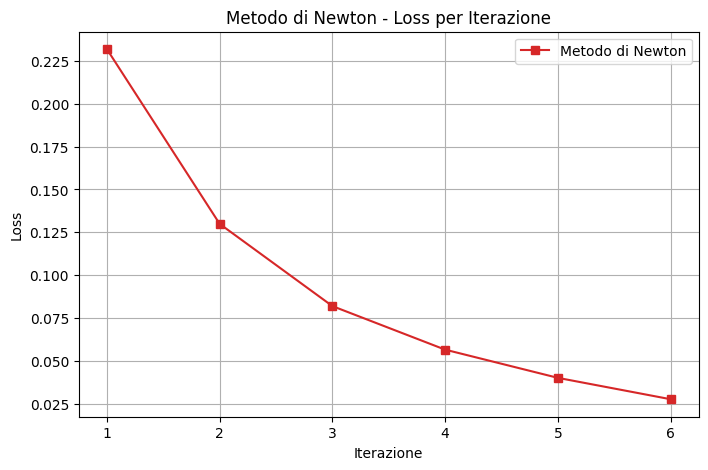

In [ ]:
n_features = X_train.shape[1]
W = np.zeros(n_features)

iterazioni = 6
loss_history_newton = []

start = time.perf_counter()

for i in range(1,iterazioni+1):
    grad = calcola_gradiente(X_train,y_train,W)
    H = calcola_hessiana(X_train,y_train,W)

    p = np.linalg.solve(H,-grad)
    # H_reg = H + 1e-6 * np.eye(H.shape[0])
    # p = np.linalg.solve(H_reg,-grad)

    W = W + p
    current_loss = calcola_loss(X_train,y_train,W)
    loss_history_newton.append(current_loss)

    print(f"Iterazione {i:02d}/{iterazioni} Loss corrente: {current_loss:.6f}")

end = time.perf_counter()

print(f"Tempo di addestramento: {end - start:.4f} s")

y_probs_train = sigmoid(X_train @ W) # probabilità predette
y_pred_train = (y_probs_train >= 0.5).astype(int) # conversione in classi 0 o 1 (soglia a 0.5)

acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("Metriche di Training:")
print(f"Accuracy:  {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall:    {rec_train:.4f}")
print(f"F1-Score:  {f1_train:.4f}")
print("\nMatrice di Confusione (Training):")
print(cm_train)

plt.figure(figsize=(8, 5))
plt.plot(range(1, iterazioni + 1), loss_history_newton, marker='s', color='tab:red', label='Metodo di Newton')
plt.title("Metodo di Newton - Loss per Iterazione")
plt.xlabel("Iterazione")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Test Newton
y_probs_test = sigmoid(X_test @ W)
y_pred_test = (y_probs_test >= 0.5).astype(int)

test_loss = calcola_loss(X_test,y_test,W)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print("Metriche di Test:")
print(f"Loss sul Test Set: {test_loss:.6f}\n")
print(f"Accuracy:  {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall:    {rec_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")
print("\nMatrice di Confusione (Test):")
print(cm_test)

Metriche di Test:
Loss sul Test Set: 0.216318

Accuracy:  0.9298
Precision: 0.9706
Recall:    0.9167
F1-Score:  0.9429

Matrice di Confusione (Test):
[[40  2]
 [ 6 66]]
